<p align="left">
  <img src="../data/escudo_uach.png" width="100">
</p>

# Estudio y análisis de sistemas oscilatorios armónicos, decremento logarítmico y funciones de transferencia

## Integrantes: Patricio Elgueda & Mateo Suárez

### Tabla de contenidos:
1) Amortiguamiento viscoso
2) Decremento logarítmico
3) Funciones de transferencia
4) Conclusiones
5) Referencias


## Un sistema masa-resorte forzado o excitado por una fuerza externa viene dado de la siguiente forma:

<p align="center">
  <img src="..\data\0.png" width="500">
</p>


$$m \ddot{x}(t) +kx(t) = f(t)$$

donde:

- $m$ es la masa;
- $k$ es la rigidez;
- $x(t)$ es el desplazamiento;
- $f(t)$ es la fuerza externa que se jerce sobre el sistema;
- $x_0$ es el desplazamiento inicial

### Si es un sistema en oscilación libre, la fuerza externa no está presente, es decir:

$$
m \ddot{x}(t) +kx(t) = 0 \quad \Longrightarrow \quad \ddot{x}(t) + \omega_n^2 x(t) = 0
$$

En la que, la frecuencia natural no amortiguada se calcula como:

$$
\omega_n = \sqrt{\frac{k}{m}} \quad \Longrightarrow \quad f_n = \frac{1}{2\pi}\sqrt{\frac{k}{m}}
$$

### La solución general a este problema viene dada por:

$$
x(t) = x_0 cos(\omega_n t - \phi)
$$

6.324555320336759


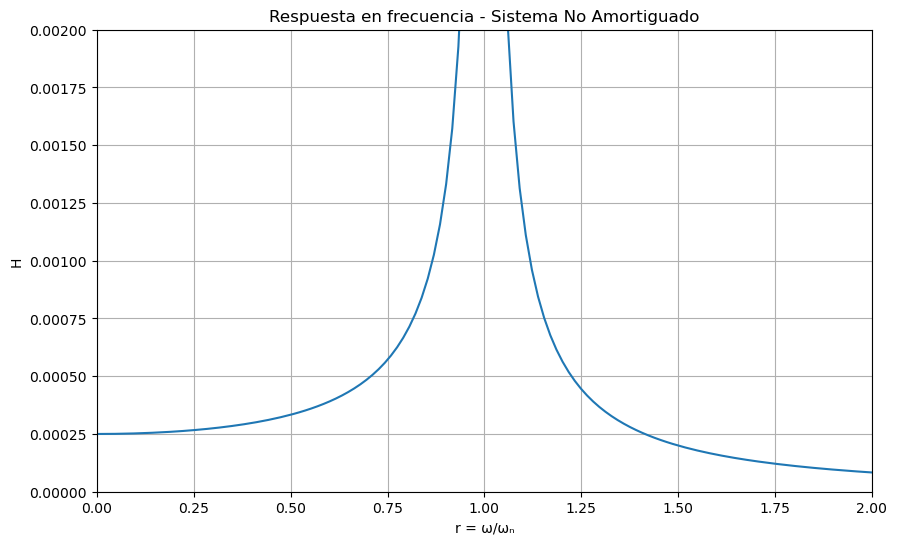

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Sistema masa-resorte No Amortiguado forzado

k = 4000 #N/m
m = 100 #Kg
w_n = np.sqrt(k/m)
print(w_n)

w = np.arange(0, 200, 0.1)
r = w/w_n
H = (1/k)*(1/(1-r**2))

plt.figure(figsize=(10,6))
plt.plot(r, np.abs(H))
plt.xlabel('r = ω/ωₙ')
plt.ylabel('H')
plt.ylim(0, 0.002)
plt.xlim(0, 2)
plt.title('Respuesta en frecuencia - Sistema No Amortiguado')
plt.grid(True)
plt.show()

## En cambio, un sistema masa-resorte amortiguado forzado se expresa de la forma:

<p align="center">
  <img src="..\data\1.png" width="500">
</p>

$$
m \ddot{x}(t) + c \dot{x}(t) + kx(t) = f(t)
$$

### Y libre:

$$
m \ddot{x}(t) + c \dot{x}(t) + kx(t) = 0 \quad \Longrightarrow \quad  \ddot{x}(t) + 2 \zeta \omega_n \dot{x}(t) + \omega_n^2 x(t) = 0
$$

donde:
- $c$ es el coeficiente de amortiguamiento
- $\zeta = \frac{c}{2 \omega_n m}$ es la razón de amortiguamiento (adimensional).
- $\omega_d = \omega_n \sqrt{1-\zeta^2}$ es la frecuencia natural amortiguada.

## Existen 3 casos para este problema:

### Sistema subamortiguado: $\zeta < 1$

donde la solución del problema viene dada por:

$$x(t) = e^{-\zeta \omega_n t}(x_o \cos(\omega_d t ) + \frac{v_0 + \zeta \omega_n x_0}{\omega_d} \sin(\omega_d t))$$

### Sistema críticamente amortiguado: $\zeta = 1$

$$x(t) = e^{-\zeta \omega_n t}(x_0 + (v_0 + \omega_n x_0)t)$$

### Sistema sobreamortiguado: $\zeta > 1$

$$x(t) = e^{-\zeta \omega_n t} \left[ x_0 \cosh(\omega_h t) + \frac{v_0 + \zeta \omega_n x_0}{\omega_h} \sinh(\omega_h t) \right]$$

donde,

$$\omega_h = \omega_n \sqrt{\zeta^2 - 1}$$

Frecuencia natural no amortiguada (fn): 10.07 Hz
Frecuencia natural amortiguada (fd): 10.05 Hz
Coeficiente de amortiguamiento viscoso (c): 9.49 N·s/m


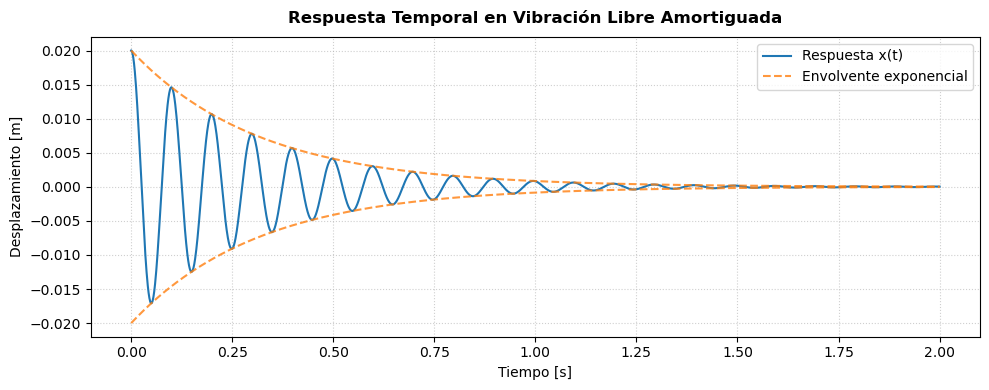

In [2]:
# Parámetros físicos del sistema SDOF
m = 1.5      # Masa (kg)
k = 6000.0   # Rigidez (N/m)
zeta = 0.05  # Razón de amortiguamiento (5%)

# Cálculos teóricos
wn = np.sqrt(k / m)
fn = wn / (2 * np.pi)
wd = wn * np.sqrt(1 - zeta**2)
fd = wd / (2 * np.pi)
c = 2 * zeta * np.sqrt(k * m)

print(f"Frecuencia natural no amortiguada (fn): {fn:.2f} Hz")
print(f"Frecuencia natural amortiguada (fd): {fd:.2f} Hz")
print(f"Coeficiente de amortiguamiento viscoso (c): {c:.2f} N·s/m")

# Simulación temporal de oscilación libre
t = np.linspace(0, 2.0, 2000)
x0 = 0.02 # Desplazamiento inicial de 2 cm
        
# Respuesta analítica para v0 = 0
x_t = x0 * np.exp(-zeta * wn * t) * (np.cos(wd * t) + (zeta / np.sqrt(1 - zeta**2)) * np.sin(wd * t))
        
# Envolventes exponenciales de decaimiento
envolvente_pos = x0 * np.exp(-zeta * wn * t)
envolvente_neg = -x0 * np.exp(-zeta * wn * t)

# Gráfico de la respuesta temporal
plt.figure(figsize=(10, 4), dpi=100)
plt.plot(t, x_t, label='Respuesta x(t)', color='#1f77b4', lw=1.5)
plt.plot(t, envolvente_pos, '--', label='Envolvente exponencial', color='#ff7f0e', alpha=0.8)
plt.plot(t, envolvente_neg, '--', color='#ff7f0e', alpha=0.8)
plt.title('Respuesta Temporal en Vibración Libre Amortiguada', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Tiempo [s]', fontsize=10)
plt.ylabel('Desplazamiento [m]', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


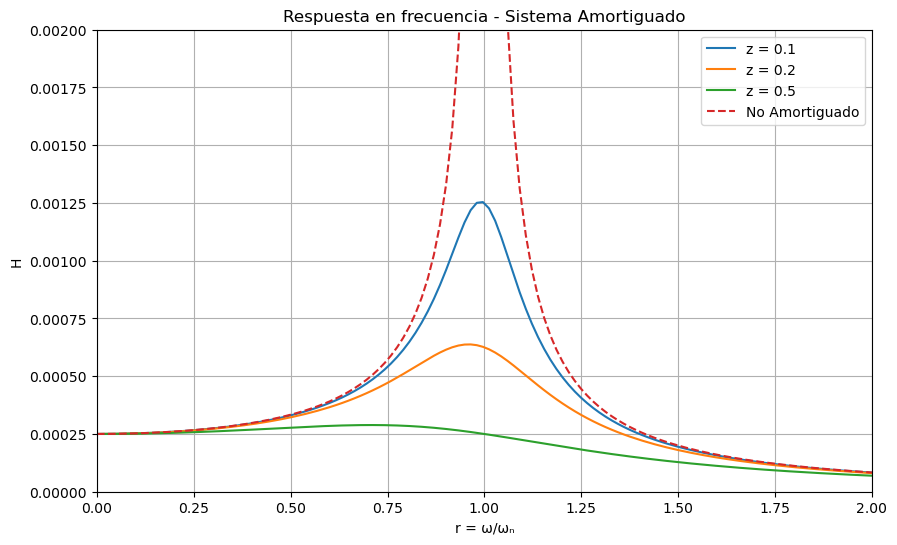

In [3]:
# Sistema masa-resorte Amortiguado forzado

k = 4000
m = 100

w_n = np.sqrt(k/m)

z = [0.1, 0.2, 0.5]

w = np.arange(0, 200, 0.1)

r = w/w_n

plt.figure(figsize=(10,6))

for z in z:

    H_amortiguado = 1/k*(1/np.sqrt((1-r**2)**2 + (2*z*r)**2))

    plt.plot(r, np.abs(H_amortiguado), label=f'z = {z}')

plt.plot(r, np.abs(H), label='No Amortiguado', linestyle='--')
plt.xlabel('r = ω/ωₙ')
plt.ylabel('H')
plt.ylim(0, 0.002)
plt.xlim(0, 2)
plt.title('Respuesta en frecuencia - Sistema Amortiguado')
plt.grid(True)
plt.legend()
plt.show()


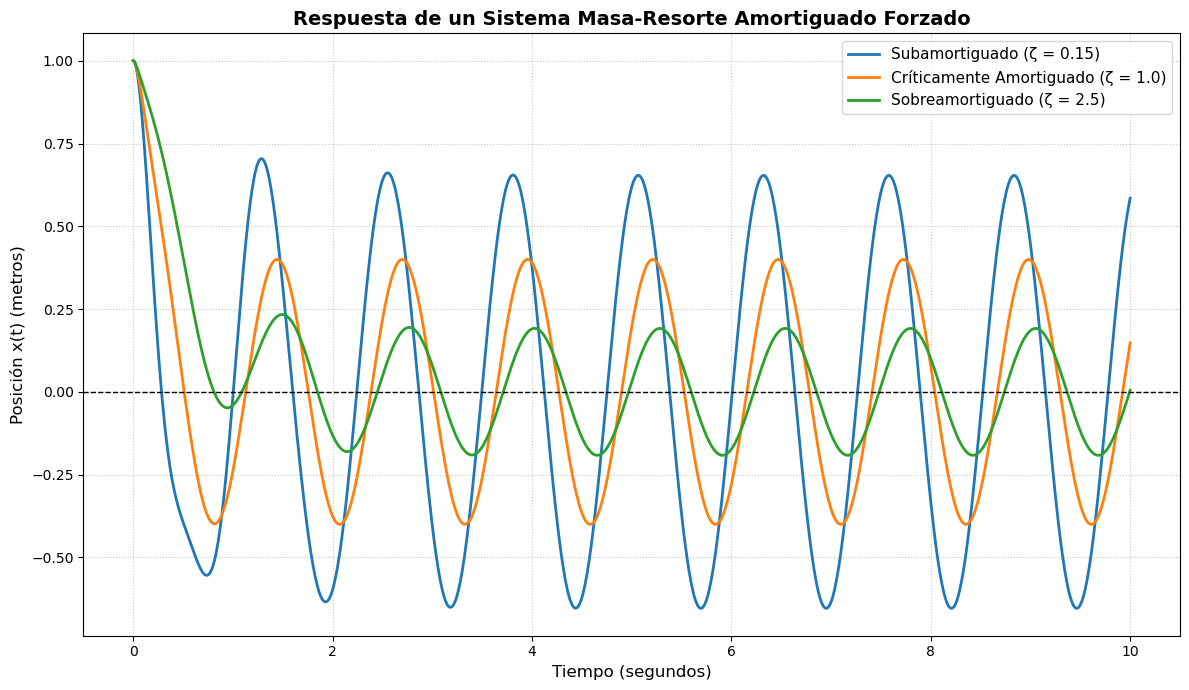

In [8]:
from scipy.integrate import odeint

# 1. Parámetros físicos del sistema
m = 1.0       # Masa (kg)
k = 100.0     # Constante del resorte (N/m)
wn = np.sqrt(k/m) # Frecuencia natural no amortiguada (rad/s)

# Parámetros de la fuerza externa F(t) = F0 * cos(w*t)
F0 = 50.0     # Amplitud de la fuerza (N)
w = 5.0       # Frecuencia de la fuerza excitadora (rad/s)

# 2. Definición de la ecuación diferencial
# Convertimos la EDO de 2do orden en un sistema de dos EDOs de 1er orden
def masa_resorte(estado, t, zeta):
    x, v = estado # x: posición, v: velocidad
    
    # Calculamos el coeficiente de amortiguamiento 'c' a partir de zeta
    c = 2 * zeta * np.sqrt(k * m)
    
    # dxdt = v
    # dvdt = (Fuerza externa - amortiguamiento - fuerza restauradora) / masa
    dxdt = v
    dvdt = (F0 * np.cos(w * t) - c * v - k * x) / m
    
    return [dxdt, dvdt]

# 3. Condiciones iniciales y tiempo
# El sistema inicia con un desplazamiento de 1 metro y en reposo (velocidad 0)
estado_inicial = [1.0, 0.0] 
tiempo = np.linspace(0, 10, 1000) # Simulación de 0 a 10 segundos

# 4. Definición de los 3 casos de amortiguamiento
casos_zeta = {
    'Subamortiguado (ζ = 0.15)': 0.15,
    'Críticamente Amortiguado (ζ = 1.0)': 1.0,
    'Sobreamortiguado (ζ = 2.5)': 2.5
}

# 5. Resolución y graficación
plt.figure(figsize=(12, 7))

# Iteramos sobre los tres casos para resolver y graficar
for etiqueta, zeta in casos_zeta.items():
    # Resolvemos el sistema usando odeint
    solucion = odeint(masa_resorte, estado_inicial, tiempo, args=(zeta,))
    
    # Extraemos la posición (columna 0)
    posicion = solucion[:, 0]
    
    # Graficamos
    plt.plot(tiempo, posicion, label=etiqueta, linewidth=2)

# Configuración visual de la gráfica
plt.title('Respuesta de un Sistema Masa-Resorte Amortiguado Forzado', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (segundos)', fontsize=12)
plt.ylabel('Posición x(t) (metros)', fontsize=12)
plt.axhline(0, color='black', linewidth=1, linestyle='--') # Línea de equilibrio
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Mostrar la gráfica
plt.show()

## Estimación del Amortiguamiento por Decremento Logarítmico

El decremento logarítmico es un método para evaluar la tasa de decaimiento de un sistema en vibración libre subamortiguada. 

Permite estimar experimentalmente la razón de amortiguamiento ($\zeta$) midiendo la amplitud de los picos en una gráfica a lo largo del tiempo. Se calcula a partir de la tasa de decaimiento entre máximos locales sucesivos separados por un número determinado de ciclos ($n$):

$$\delta = \frac{1}{n} \ln\left(\frac{x_i}{x_{i+n}}\right)$$

Donde:
- $\delta$: Decremento logarítmico.
- $n$: Número de ciclos completos transcurridos.
- $x_i$: Amplitud del pico inicial.
- $x_{i+n}$: Amplitud del pico después de $n$ ciclos.

Una vez determinado el valor de $\delta$, la razón de amortiguamiento ($\zeta$) se calcula mediante la relación exacta:

$$\zeta = \frac{\delta}{\sqrt{4\pi^2 + \delta^2}}$$


In [10]:

x0 = 1.0        # Amplitud inicial (metros)
zeta = 0.15     # Razón de amortiguamiento teórica (para simular el sistema)
wn = 10.0       # Frecuencia natural no amortiguada (rad/s)

# Cálculo de frecuencias derivadas
wd = wn * np.sqrt(1 - zeta**2) # Frecuencia natural amortiguada (rad/s)
fd = wd / (2 * np.pi)          # Frecuencia amortiguada en Hz (ciclos/segundo)



# Simulación de estimación basada en máximos locales
n_ciclos = 5
t_pico_0 = 0.0
x_pico_0 = x0

# El periodo amortiguado es T_d = 1 / f_d
Td = 1 / fd
t_pico_n = n_ciclos * Td

# Calculamos la amplitud exacta en el ciclo 'n' usando la envolvente
x_pico_n = x0 * np.exp(-zeta * wn * t_pico_n)

# Cálculo del decremento logarítmico estimado
delta_est = (1 / n_ciclos) * np.log(x_pico_0 / x_pico_n)

# Cálculo de la razón de amortiguamiento a partir de delta
zeta_est = delta_est / np.sqrt(4 * np.pi**2 + delta_est**2)



print("--- Estimación por Decremento Logarítmico ---")
print(f"Amplitud Pico inicial (x_0): {x_pico_0:.5f} m")
print(f"Amplitud Pico tras {n_ciclos} ciclos (x_n): {x_pico_n:.5f} m")
print(f"Decremento Logarítmico (δ): {delta_est:.4f}")
print(f"Razón de amortiguamiento estimada (ζ): {zeta_est:.4f} (Valor Teórico: {zeta})")

--- Estimación por Decremento Logarítmico ---
Amplitud Pico inicial (x_0): 1.00000 m
Amplitud Pico tras 5 ciclos (x_n): 0.00851 m
Decremento Logarítmico (δ): 0.9533
Razón de amortiguamiento estimada (ζ): 0.1500 (Valor Teórico: 0.15)


--- Resultados del Análisis de Picos ---
Pico Inicial seleccionado: Tiempo = 1.24 s, Amplitud (x1) = 0.6058
Pico Final seleccionado  : Tiempo = 6.29 s, Amplitud (x2) = 0.0806
Ciclos transcurridos (n) : 4
Decremento Logarítmico (δ): 0.5042
Razón de amortiguamiento calculada (ζ): 0.0800
Razón de amortiguamiento real del sistema: 0.0800


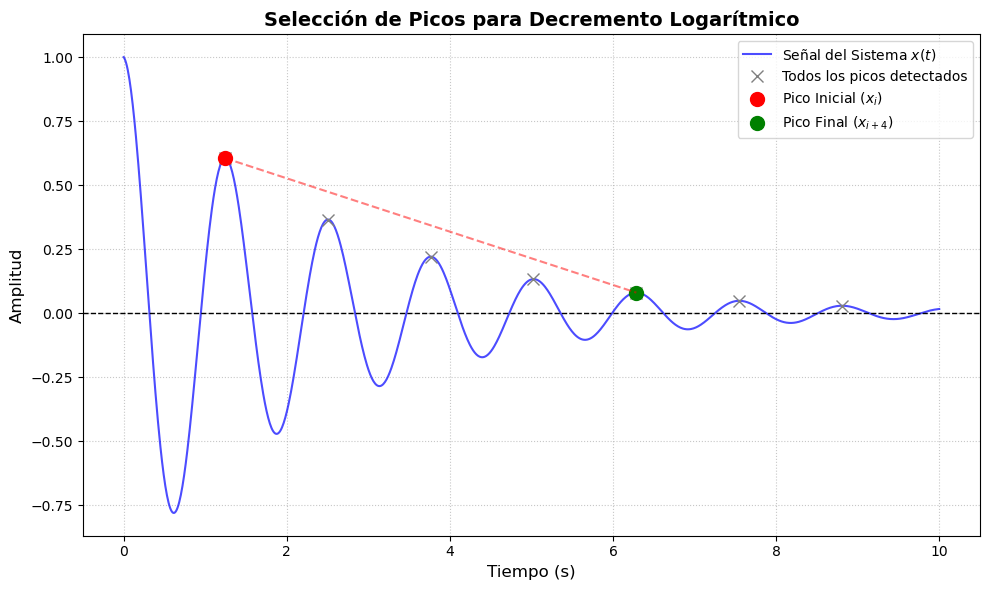

In [11]:
from scipy.signal import find_peaks


# Parámetros del sistema
x0 = 1.0           # Desplazamiento inicial
zeta_real = 0.08   # Razón de amortiguamiento (el valor que queremos descubrir)
wn = 5.0           # Frecuencia natural (rad/s)
wd = wn * np.sqrt(1 - zeta_real**2) # Frecuencia amortiguada

# Vector de tiempo (de 0 a 10 segundos)
t = np.linspace(0, 10, 1000)

# Ecuación del movimiento subamortiguado (condiciones iniciales x(0)=x0, v(0)=0 aprox)
# Usamos cos() para que el primer pico esté cerca de t=0
x = x0 * np.exp(-zeta_real * wn * t) * np.cos(wd * t)


# find_peaks encuentra los índices del array 'x' donde ocurren máximos locales
indices_picos, _ = find_peaks(x)

# Extraemos el tiempo y la amplitud de esos picos detectados
t_picos = t[indices_picos]
x_picos = x[indices_picos]


# Aquí decidimos qué picos usar para nuestro cálculo de decremento.
# Elegiremos el primer pico detectado y otro 'n' ciclos después.
indice_inicial = 0  # Tomamos el primer pico (índice 0)
n_ciclos = 4        # Queremos mirar 4 ciclos más adelante
indice_final = indice_inicial + n_ciclos

# Extraemos los valores específicos que usaremos en la fórmula
t1 = t_picos[indice_inicial]
x1 = x_picos[indice_inicial]

t2 = t_picos[indice_final]
x2 = x_picos[indice_final]


# Aplicamos la fórmula matemática con los datos extraídos
delta_calculado = (1 / n_ciclos) * np.log(x1 / x2)
zeta_calculado = delta_calculado / np.sqrt(4 * np.pi**2 + delta_calculado**2)

print("--- Resultados del Análisis de Picos ---")
print(f"Pico Inicial seleccionado: Tiempo = {t1:.2f} s, Amplitud (x1) = {x1:.4f}")
print(f"Pico Final seleccionado  : Tiempo = {t2:.2f} s, Amplitud (x2) = {x2:.4f}")
print(f"Ciclos transcurridos (n) : {n_ciclos}")
print(f"Decremento Logarítmico (δ): {delta_calculado:.4f}")
print(f"Razón de amortiguamiento calculada (ζ): {zeta_calculado:.4f}")
print(f"Razón de amortiguamiento real del sistema: {zeta_real:.4f}")


plt.figure(figsize=(10, 6))

# Graficamos la señal completa
plt.plot(t, x, label='Señal del Sistema $x(t)$', color='blue', alpha=0.7)

# Marcamos TODOS los picos detectados
plt.plot(t_picos, x_picos, "x", color='gray', markersize=8, label='Todos los picos detectados')

# Resaltamos los picos SELECCIONADOS para el cálculo
plt.plot(t1, x1, "o", color='red', markersize=10, label=f'Pico Inicial ($x_i$)')
plt.plot(t2, x2, "o", color='green', markersize=10, label=f'Pico Final ($x_{{i+{n_ciclos}}}$)')

# Dibujamos una línea conectando los picos seleccionados para ilustrar el decaimiento
plt.plot([t1, t2], [x1, x2], '--', color='red', alpha=0.5)

plt.title('Selección de Picos para Decremento Logarítmico', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (s)', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

## Funciones de transferencia, Respuesta en Frecuencia (FRF) y Regiones de control dinámico

La función de transferencia que relaciona la respuesta estacionaria en desplazamiento con una excitación armónica de fuerza de entrada se define como **Admitancia Dinámica** o **Receptancia**:

### Dado un sistema masa-resorte forzado:

$$m \ddot{x}(t) +kx(t) = f(t)$$

Si se aplica la Transformada de Fourier,

$$ (j \omega)^2 m \mathbf{X}(\omega) +k\mathbf{X}(\omega) = \mathbf{F}(\omega)$$

despejando,

$$ \frac{\mathbf{X}(\omega)}{\mathbf{F}(\omega)} =  \frac{1}{k - m\omega^2} = \mathbf{H}(\omega) $$

donde $\mathbf{H}(\omega)$ es la funcion de transferencia del sistema, denominada como **Receptancia**. Ahora, si se quiere expresar en base a la frecuencia natural:

$$  \mathbf{H}(\omega)  =  \frac{1/k}{1 - \frac{\omega^2}{\omega_n^2}}$$

### Dado un sistema masa-resorte-amortiguado forzado:

$$
m \ddot{x}(t) + c \dot{x}(t) + kx(t) = f(t)
$$

Si se aplica la Transformada de Fourier,

$$ (j \omega)^2 m \mathbf{X}(\omega) + j \omega c \mathbf{X}(\omega) +k\mathbf{X}(\omega) = \mathbf{F}(\omega)$$

despejando,

$$ \frac{\mathbf{X}(\omega)}{\mathbf{F}(\omega)} = \mathbf{H}(\omega) = \frac{1}{(k - m\omega^2) + j(c\omega)}$$

$$ \Longrightarrow \mathbf{H}(\omega) = \frac{1/k}{(1 - \frac{\omega}{\omega_n}) + 2j \zeta \frac{\omega^2}{\omega_n^2}}$$

donde $\mathbf{H}(\omega)$ es la FRF del sistema, denominada como **Admitancia**. 

### Regiones de control dinámico:
El denominador está compuesto por tres fuerzas que dominan el comportamiento según la frecuencia de excitación $\omega$:

1. **Control por Rigidez (Baja Frecuencia: $\omega \ll \omega_n$):** Los términos inerciales y de amortiguamiento son pequeños. $H(\omega) \approx \frac{1}{k}$. La respuesta es proporcional a la flexibilidad elástica y la fase es cercana a $0^\circ$.
2. **Control por Amortiguamiento (Resonancia: $ \omega \approx \omega_n\ $ ):** Los términos de masa y rigidez se cancelan recíprocamente ($k - m\omega^2 = 0$). La amplitud máxima del pico está gobernada enteramente por el amortiguamiento: $ H(\omega) \approx \frac{1}{j c \omega} $. La fase cruza exactamente por $-90^\circ$.
3. **Control por Masa (Alta Frecuencia: $\omega \gg \omega_n$):** El término inercial domina masivamente. La admitancia decrece exponencialmente a una tasa de $1/\omega^2$: $H(\omega) \approx -\frac{1}{m\omega^2}$. La respuesta se desfasa por completo quedando a $-180^\circ$.

### Clasificación de FRFs comunes:
* **Receptancia / Admitancia ($H$):** $\frac{\text{Desplazamiento}}{\text{Fuerza}}$
* **Movilidad ($Y$):** $\frac{\text{Velocidad}}{\text{Fuerza}} = j\omega H(\omega)$
* **Acelerancia ($A$):** $\frac{\text{Aceleración}}{\text{Fuerza}} = -\omega^2 H(\omega)$ *(Muy utilizada en la práctica industrial mediante acelerómetros)*


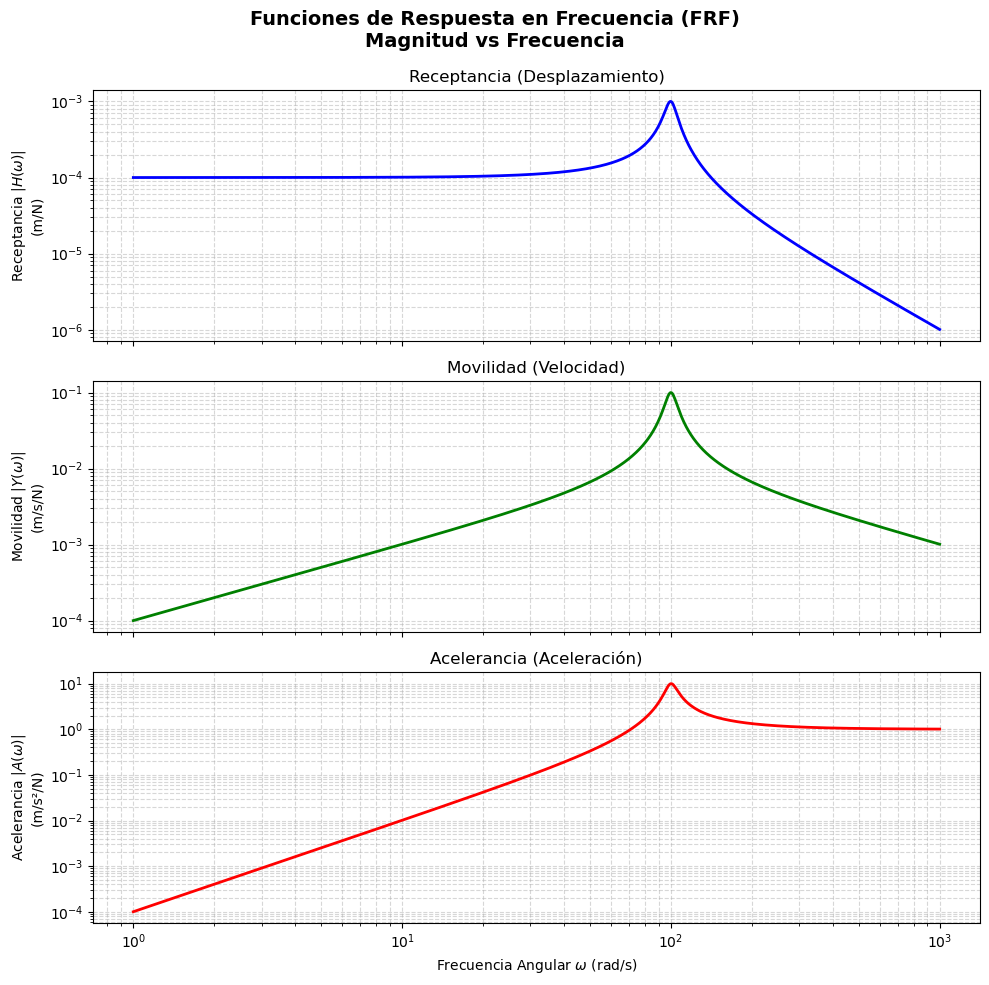

In [14]:

m = 1.0       # Masa (kg)
k = 10000.0   # Rigidez del resorte (N/m)
zeta = 0.05   # Razón de amortiguamiento (5%)

# Frecuencia natural y coeficiente de amortiguamiento
wn = np.sqrt(k / m) 
c = 2 * zeta * np.sqrt(k * m)

# 2. Vector de frecuencias de excitación (omega)
# Usamos una escala logarítmica desde 1 rad/s hasta 1000 rad/s
w = np.logspace(0, 3, 1000)

# 3. Cálculo de las FRF complejas
# Denominador común: (k - m*w^2) + j*(c*w)
denominador = (k - m * w**2) + 1j * (c * w)

# Receptancia (H): Desplazamiento / Fuerza
H = 1.0 / denominador

# Movilidad (Y): Velocidad / Fuerza = j*w*H
Y = (1j * w) * H

# Acelerancia (A): Aceleración / Fuerza = -w^2*H
A = -(w**2) * H

# 4. Configuración de la gráfica
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Título general
fig.suptitle('Funciones de Respuesta en Frecuencia (FRF)\nMagnitud vs Frecuencia', fontsize=14, fontweight='bold')

# Graficar Receptancia
axs[0].loglog(w, np.abs(H), color='blue', linewidth=2)
axs[0].set_ylabel('Receptancia $|H(\omega)|$\n(m/N)')
axs[0].set_title('Receptancia (Desplazamiento)')
axs[0].grid(True, which="both", ls="--", alpha=0.5)

# Graficar Movilidad
axs[1].loglog(w, np.abs(Y), color='green', linewidth=2)
axs[1].set_ylabel('Movilidad $|Y(\omega)|$\n(m/s/N)')
axs[1].set_title('Movilidad (Velocidad)')
axs[1].grid(True, which="both", ls="--", alpha=0.5)

# Graficar Acelerancia
axs[2].loglog(w, np.abs(A), color='red', linewidth=2)
axs[2].set_ylabel('Acelerancia $|A(\omega)|$\n(m/s²/N)')
axs[2].set_title('Acelerancia (Aceleración)')
axs[2].set_xlabel('Frecuencia Angular $\omega$ (rad/s)')
axs[2].grid(True, which="both", ls="--", alpha=0.5)

# Mostrar la gráfica
plt.tight_layout()
plt.subplots_adjust(top=0.9) # Ajustar para que el título no se superponga
plt.show()

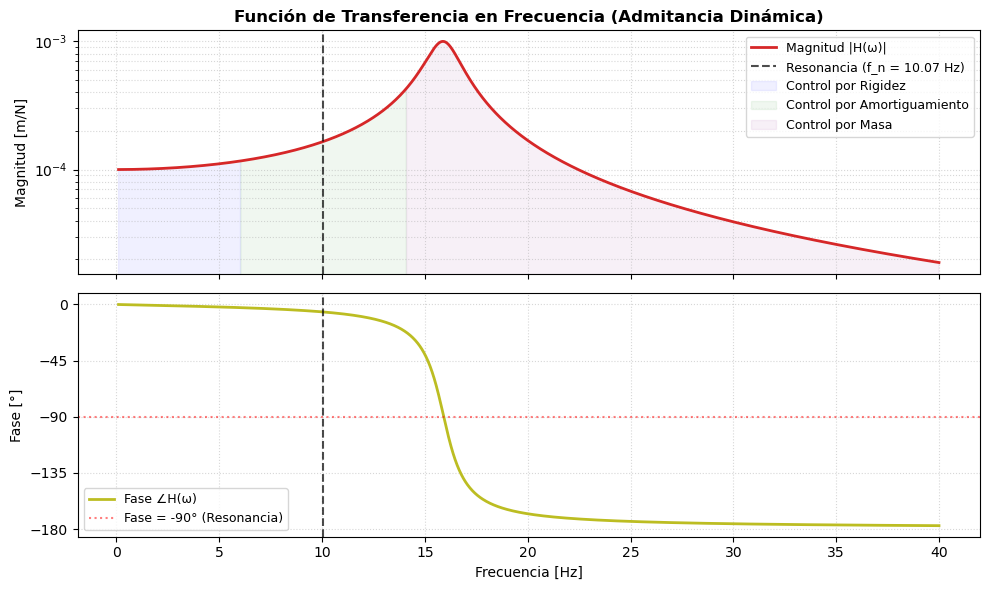

In [15]:
# Frecuencias para evaluar el espectro de la FRF
f_frf = np.linspace(0.1, 40, 2000)
w_frf = 2 * np.pi * f_frf

# Calcular Función de Transferencia H(ω)
H_w = 1 / ((k - m * w_frf**2) + 1j * c * w_frf)

# Magnitud y Fase de la Receptancia
mag_H = np.abs(H_w)
fase_H = np.angle(H_w, deg=True)

# Graficar Magnitud y Fase
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, dpi=100)

# Graficar Magnitud con sombreado de zonas de control dinámico
ax1.semilogy(f_frf, mag_H, color='#d62728', lw=2, label='Magnitud |H(ω)|')
ax1.axvline(fn, color='black', linestyle='--', alpha=0.7, label=f'Resonancia (f_n = {fn:.2f} Hz)')

ax1.fill_between(f_frf, 0, mag_H, where=(f_frf < fn*0.6), color='blue', alpha=0.06, label='Control por Rigidez')
ax1.fill_between(f_frf, 0, mag_H, where=((f_frf >= fn*0.6) & (f_frf <= fn*1.4)), color='green', alpha=0.06, label='Control por Amortiguamiento')
ax1.fill_between(f_frf, 0, mag_H, where=(f_frf > fn*1.4), color='purple', alpha=0.06, label='Control por Masa')

ax1.set_title('Función de Transferencia en Frecuencia (Admitancia Dinámica)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Magnitud [m/N]', fontsize=10)
ax1.grid(True, which="both", linestyle=':', alpha=0.5)
ax1.legend(loc='upper right', fontsize=9)

# Graficar Fase
ax2.plot(f_frf, fase_H, color='#bcbd22', lw=2, label='Fase ∠H(ω)')
ax2.axvline(fn, color='black', linestyle='--', alpha=0.7)
ax2.axhline(-90, color='r', linestyle=':', alpha=0.5, label='Fase = -90° (Resonancia)')
ax2.set_xlabel('Frecuencia [Hz]', fontsize=10)
ax2.set_ylabel('Fase [°]', fontsize=10)
ax2.set_yticks([0, -45, -90, -135, -180])
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()
